In [1]:
import numpy as np
import math
import statistics
import pandas as pd
import pyswarms as ps
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, mean_squared_error
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import time
import warnings
warnings.filterwarnings("ignore")

In [2]:
def yes_function(x, y, a, kappa, lam, gamma=1):
    return 1 - np.maximum(0.0, ((1-x)**kappa + (1-y)**kappa - (1-a)**kappa))**(1/kappa)

def no_function(x, y, a, kappa, lam, gamma=1):
    return np.maximum(0.0, (x**lam + y**lam - a**lam))**(1/lam)

def maybe_function(x, y, a, kappa, lam, gamma=1):
    if x is None or y is None:
        return 0
    if gamma == 0:
        return 0
    a = np.clip(a, 1e-6, 1 - 1e-6)
    x = np.clip(x, 0, 1)
    y = np.clip(y, 0, 1)
    value = gamma*(1/a)*x*y + (1-gamma)*(1 - (1/(1-a))*(1-x)*(1-y))
    return statistics.median([0, 1, value])

def classification(x, y, a, kappa, lam, gamma):
    if x < a and y < a:
        return no_function(x, y, a, 1, lam, 1)
    elif x > a and y > a:
        return yes_function(x, y, a, kappa, 1, 1)
    else:
        return maybe_function(x, y, a, 1, 1, gamma)

def classification_vec(values, diffs, a, kappa, lam, gamma):
    if values.size == 0 or diffs.size == 0:
        return np.zeros_like(values)

    results = np.zeros_like(values, dtype=float)
    mask_no    = (values < a) & (diffs < a)
    mask_yes   = (values > a) & (diffs > a)
    mask_maybe = ~(mask_no | mask_yes)

    if np.any(mask_no):
        results[mask_no] = no_function(values[mask_no], diffs[mask_no], a, 1, lam, 1)
    if np.any(mask_yes):
        results[mask_yes] = yes_function(values[mask_yes], diffs[mask_yes], a, kappa, 1, 1)
    if np.any(mask_maybe):
        for idx in np.where(mask_maybe)[0]:
            results[idx] = maybe_function(values[idx], diffs[idx], a, 1, 1, gamma)

    return np.round(results, 4)

def evaluate_params(X, y, params):
    n_features = X.shape[1]
    value = np.abs(X[:, 0] - params[5])
    i = 6
    for j in range(n_features - 1):
        diff = np.abs(X[:, j+1] - params[i])
        value = classification_vec(value, diff,
                                   params[0], params[1], params[2], params[3])
        i += 1

    error = np.exp2(np.abs(value - y))
    calc_class   = (value >= params[0]).astype(int)
    target_class = (y >= params[0]).astype(int)
    mean_error   = np.mean(error)
    f1           = f1_score(target_class, calc_class, zero_division=0)

    return value, error, calc_class, target_class, mean_error, f1

def make_cost_func(X_train, y_train):
    n_features = X_train.shape[1]

    def cost_func(position_matrix):
        n_particles = position_matrix.shape[0]
        costs = np.zeros(n_particles)

        for i, param in enumerate(position_matrix):
            try:
                param = np.clip(param, 0, 1)
                param[0] = np.clip(param[0], 0.3, 0.7)
                param[1] = param[1] * 3
                param[2] = param[2] * 3

                value = np.abs(X_train[:, 0] - param[5])
                idx = 6
                for j in range(n_features - 1):
                    diff = np.abs(X_train[:, j+1] - param[idx])
                    value = classification_vec(value, diff,
                                               param[0], param[1], param[2], param[3])
                    idx += 1

                if np.any(np.isnan(value)) or np.any(np.isinf(value)):
                    costs[i] = 1e9
                    continue

                error    = np.exp2(np.abs(value - y_train))
                fitness1 = 1.0 / (math.sqrt(np.mean(error)) + 1e-8)

                calc_class   = (value >= param[0]).astype(int)
                target_class = (y_train >= param[0]).astype(int)
                fitness2     = f1_score(target_class, calc_class, zero_division=0)

                if np.isnan(fitness1) or np.isnan(fitness2):
                    costs[i] = 1e9
                    continue

                costs[i] = -(param[4] * fitness1 + (1 - param[4]) * fitness2)

            except Exception as e:
                print(f"Cost calculation failed: {e}")
                costs[i] = 1e9

        return costs

    return cost_func

def run_pso_on_fold(X_train_fold, y_train_fold):
    n_genes=100

    bounds = (
        np.zeros(n_genes),  
        np.ones(n_genes)     
    )

    options = {
        'c1': 0.5,  
        'c2': 0.5,   
        'w':  0.9    
    }

    optimizer = ps.single.GlobalBestPSO(
        n_particles=30,
        dimensions=100,
        options=options,
        bounds=bounds
    )

    cost_func = make_cost_func(X_train_fold, y_train_fold)

    best_cost, best_pos = optimizer.optimize(
        cost_func,
        iters=60,
        verbose=False
    )

    best_params = best_pos.copy()
    best_params = np.clip(best_params, 0, 1)
    best_params[0] = np.clip(best_params[0], 0.3, 0.7)  # a
    best_params[1] = best_params[1] * 3                  # kappa
    best_params[2] = best_params[2] * 3                  # lambda

    return best_params, best_cost

def calculate_param_using_pso(data: pd.DataFrame, n_splits: int = 10):
    df = data.copy()
    X = df.iloc[:, :-1].to_numpy()
    y = df.iloc[:, -1].to_numpy()

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    cv_results = []

    print(f"{n_splits}-fold cross-validation")
    print("=" * 60)

    for fold_idx, (train_index, val_index) in enumerate(kf.split(X), start=1):
        print(f"\n--- Fold {fold_idx}/{n_splits} ---")

        X_train_fold = X[train_index]
        y_train_fold = y[train_index]
        X_val_fold   = X[val_index]
        y_val_fold   = y[val_index]

        best_params, best_cost = run_pso_on_fold(X_train_fold, y_train_fold)

        (train_values, train_errors,
         train_calc_class, train_target_class,
         train_mean_error, train_f1) = evaluate_params(X_train_fold, y_train_fold, best_params)

        (val_values, val_errors,
         val_calc_class, val_target_class,
         val_mean_error, val_f1) = evaluate_params(X_val_fold, y_val_fold, best_params)

        print(f"  Train -> Mean Error: {train_mean_error:.4f} | F1: {train_f1:.4f}")
        print(f"  Val   -> Mean Error: {val_mean_error:.4f}  | F1: {val_f1:.4f}")
        print(f"  Params -> a={best_params[0]:.4f}, kappa={best_params[1]:.4f}, "
              f"lambda={best_params[2]:.4f}, gamma={best_params[3]:.4f}")

        fold_result = {
            "fold":         fold_idx,
            "train_indices": train_index.tolist(),
            "val_indices":   val_index.tolist(),
            "train_size":    len(train_index),
            "val_size":      len(val_index),

            "best_params":    best_params,
            "a":              best_params[0],
            "kappa":          best_params[1],
            "lambda":         best_params[2],
            "gamma":          best_params[3],
            "fitness_weight": best_params[4],
            "binary_params":  best_params[5:].tolist(),
            "best_cost":      best_cost,

            "train_mean_error":  train_mean_error,
            "train_f1":          train_f1,
            "train_values":      train_values.tolist(),
            "train_errors":      train_errors.tolist(),
            "train_calc_class":  train_calc_class.tolist(),
            "train_target_class": train_target_class.tolist(),

            "val_mean_error":  val_mean_error,
            "val_f1":          val_f1,
            "val_values":      val_values.tolist(),
            "val_errors":      val_errors.tolist(),
            "val_calc_class":  val_calc_class.tolist(),
            "val_target_class": val_target_class.tolist(),

            "X_train_fold": X_train_fold.tolist(),
            "y_train_fold": y_train_fold.tolist(),
            "X_val_fold":   X_val_fold.tolist(),
            "y_val_fold":   y_val_fold.tolist(),
        }
        cv_results.append(fold_result)

    print("\n" + "=" * 60)
    print("=" * 60)

    summary_df = pd.DataFrame([{
        "Fold":            r["fold"],
        "Train Size":      r["train_size"],
        "Val Size":        r["val_size"],
        "Train MeanError": round(r["train_mean_error"], 4),
        "Train F1":        round(r["train_f1"], 4),
        "Val MeanError":   round(r["val_mean_error"], 4),
        "Val F1":          round(r["val_f1"], 4),
        "a":               round(r["a"], 4),
        "kappa":           round(r["kappa"], 4),
        "lambda":          round(r["lambda"], 4),
        "gamma":           round(r["gamma"], 4),
        "PSO Cost":        round(r["best_cost"], 4),
    } for r in cv_results])

    print(summary_df.to_string(index=False))
    print(f"\nVal F1:         {summary_df['Val F1'].mean():.4f} ± {summary_df['Val F1'].std():.4f}")
    print(f" Val Mean Error: {summary_df['Val MeanError'].mean():.4f} ± {summary_df['Val MeanError'].std():.4f}")

    best_fold_idx    = summary_df["Val F1"].idxmax()
    best_fold_result = cv_results[best_fold_idx]
    print(f"\nThe bestfold: Fold {best_fold_result['fold']}")

    return cv_results, best_fold_result, summary_df

In [3]:
def show_results(data, mean_error, gamma_result, lam_result, kappa_result, a_result):
    target_values = data[['target']].values
    value = data[['calc_value']].values
    MSE = mean_squared_error(target_values, value)
    RMSE = math.sqrt(MSE)
    print('Results:')
    if all(col in data.columns for col in ['value','error']):
      print(data.drop(columns=['value','error']))
    else:
      print(data)
    print('\u03B3 = ', round(gamma_result, 4))
    print('\u03BB = ', round(lam_result, 4))
    print('\u03BA = ', round(kappa_result, 4))
    print('a = ', round(a_result, 4))
    print('Mean squared error = ', round(MSE, 4))
    print('Root Mean Square Error = ', round(RMSE, 4))

In [4]:
def calculate_tests(target_values, value):
  print('Accuracy score = ', accuracy_score(target_values, value))
  print('F1 = ', f1_score(target_values, value, average= 'macro'))
  print('Precision = ', precision_score(target_values, value, average= 'macro'))
  print('Recall = ', recall_score(target_values, value, average= 'macro'))
  confusion_matrix = metrics.confusion_matrix(target_values, value)
  cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
  cm_display.plot()
  plt.show()

In [5]:
def normalize_target(price):
    if price > 7300:
        return 1.0
    elif price < 2160:
        return 0.0
    elif 2160 <= price <= 7300:
        return (price - 2160) / (7300 - 2160)
    else:
        return 0.0 

In [6]:
data = pd.read_csv('ostrava_housing.csv')
data['target_Normalized']=data['target'].apply(normalize_target)

# decreasing
columns_to_keep = [
    'ownership', 'energy_label', 'state', 'equipment', 'crime_index', 'quality_index'
]
for col in columns_to_keep:
    min_val = data[col].min()
    max_val = data[col].max()
    data[f"{col}_Normalized"] = 1- ((data[col] - min_val) / (max_val - min_val))

# increasing
columns_to_keep = [
    'area', 'rooms'
]
for col in columns_to_keep:
    min_val = data[col].min()
    max_val = data[col].max()
    data[f"{col}_Normalized"] = (data[col] - min_val) / (max_val - min_val)

preprocessed_data = data[[col for col in data.columns if col.endswith('_Normalized')]]
df_final = preprocessed_data.iloc[:,[2,3,4,5,6,1,8,7,0]]
df_final = df_final.rename(columns={'target_Normalized': 'target'})

X_train, X_test = train_test_split(df_final, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=df_final.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=df_final.columns)

print(X_train_scaled.head())

   energy_label_Normalized  state_Normalized  equipment_Normalized  \
0                      0.0               0.0                   0.0   
1                      0.0               1.0                   0.5   
2                      0.0               0.0                   0.0   
3                      0.0               0.0                   0.0   
4                      0.0               0.0                   0.5   

   crime_index_Normalized  quality_index_Normalized  ownership_Normalized  \
0                0.642066                       1.0                   1.0   
1                0.000000                       1.0                   1.0   
2                0.575646                       1.0                   1.0   
3                0.516605                       0.5                   1.0   
4                0.608856                       0.5                   1.0   

   rooms_Normalized  area_Normalized    target  
0          0.333333         0.140541  0.550584  
1          0.50000

In [8]:
start_time = time.time()
cv_results, best_fold_result, summary_df = calculate_param_using_pso(X_train_scaled)
print('time:', (time.time()-start_time)/60)

10-fold cross-validation

--- Fold 1/10 ---
  Train -> Mean Error: 1.1829 | F1: 0.5559
  Val   -> Mean Error: 1.1852  | F1: 0.5849
  Params -> a=0.3000, kappa=2.4451, lambda=0.8341, gamma=0.8286

--- Fold 2/10 ---
  Train -> Mean Error: 1.1689 | F1: 0.6235
  Val   -> Mean Error: 1.1687  | F1: 0.5846
  Params -> a=0.3000, kappa=1.7521, lambda=2.0507, gamma=0.5504

--- Fold 3/10 ---
  Train -> Mean Error: 1.2185 | F1: 0.6291
  Val   -> Mean Error: 1.2483  | F1: 0.6835
  Params -> a=0.3190, kappa=0.4834, lambda=2.0384, gamma=0.2398

--- Fold 4/10 ---
  Train -> Mean Error: 1.1460 | F1: 0.7340
  Val   -> Mean Error: 1.1383  | F1: 0.6780
  Params -> a=0.3000, kappa=1.4442, lambda=0.9467, gamma=0.5445

--- Fold 5/10 ---
  Train -> Mean Error: 1.2201 | F1: 0.5668
  Val   -> Mean Error: 1.2016  | F1: 0.6512
  Params -> a=0.3000, kappa=0.7385, lambda=1.9589, gamma=0.7433

--- Fold 6/10 ---
  Train -> Mean Error: 1.1699 | F1: 0.7357
  Val   -> Mean Error: 1.1657  | F1: 0.7600
  Params -> a=0.300

Accuracy score =  0.6410635155096012
F1 =  0.6107243592170521
Precision =  0.6494100024455857
Recall =  0.7275372439478585


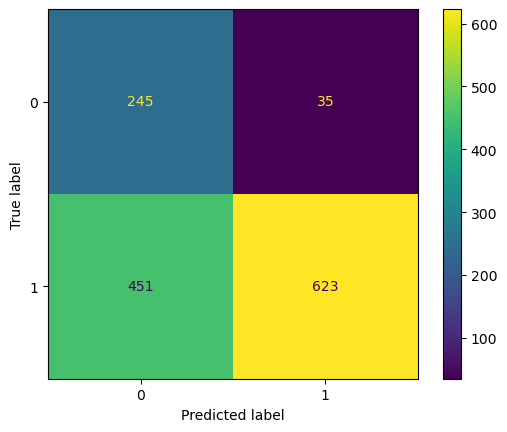

In [9]:
columns=len(X_train_scaled.columns)
X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_train_scaled['calc_value']=X_train_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
X_train_scaled['calc_value_class'] = X_train_scaled.apply(lambda row: 0 if (row['calc_value']< best_fold_result['a'])else 1, axis=1)
X_train_scaled['target_class'] = X_train_scaled.apply(lambda row: 0 if (row['target']<= best_fold_result['a'])else 1, axis=1)
calculate_tests(X_train_scaled[["calc_value_class"]].values, X_train_scaled[['target_class']].values)

In [10]:
columns=len(X_test_scaled.columns)
X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: row[0], axis =1)
j=0
while j < columns-2:
  X_test_scaled['calc_value']=X_test_scaled.apply(lambda row: classification(row['calc_value'], row[j+1], best_fold_result['a'], best_fold_result['kappa'], best_fold_result['lambda'], best_fold_result['gamma']), axis = 1)
  j += 1
show_results(X_test_scaled, 0, 0, 0, 0, 0)

Results:
     energy_label_Normalized  state_Normalized  equipment_Normalized  \
0                        0.6               0.5                   0.5   
1                        0.0               0.0                   0.0   
2                        0.0               0.0                   0.0   
3                        0.0               0.0                   0.0   
4                        0.0               0.5                   0.0   
..                       ...               ...                   ...   
334                      0.0               0.5                   0.5   
335                      0.6               1.0                   0.5   
336                      0.0               1.0                   1.0   
337                      0.6               1.0                   1.0   
338                      0.6               1.0                   0.5   

     crime_index_Normalized  quality_index_Normalized  ownership_Normalized  \
0                  0.719557                    

In [11]:
X_test_scaled['target_class'] = X_test_scaled.apply(lambda row: 0 if (row['target']< best_fold_result['a'])else 1, axis=1)
X_test_scaled['calc_value_class'] = X_test_scaled.apply(lambda row: 0 if (row['calc_value']< best_fold_result['a'])else 1, axis=1)

In [12]:
target_values = X_test_scaled[['target_class']].values
value = X_test_scaled[['calc_value_class']].values

Accuracy score =  0.6755162241887905
F1 =  0.6623261373514924
Precision =  0.7770143072289157
Recall =  0.7076190476190476


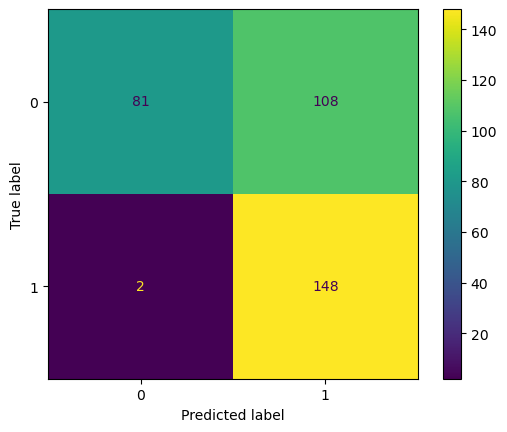

In [13]:
calculate_tests(target_values, value)